# Exercise 6: June 16, 2025

# Numerical Integration and Differentiation

In this exercise we will try writing our own code to do numerical integration and differentiation of different functions and data sets. We'll write code ourselves using the methods outlined in the lecture notebook, and then you can check your work against NumPy's built in functions.

# Integration

**Question 1.** We will first try integrating a few simple functions, where you can easily calculate what the answer should be by hand to check yourself.

Write a code to integrate the function $y=x^2$ from 0 to 5 using the trapezoid rule. Also calculate that integral by hand so you know what answer you should get. If your code is not giving the right answer, then you know there is a problem with the code you need to figure out.  

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [ ]:
x = np.linspace(0,5,100)
y = x**2

heights = y[0:(len(x)-1):1] + y[1::1]
heights = np.array(heights)
heights = heights.astype(float)

bases = x[1::1] - x[0:(len(x)-1):1]
bases = np.array(bases)
bases = bases.astype(float)

area = sum((1/2)*(heights)*(bases))
print(area)

41.66879230010543


**Question 2.** If you have not already, turn your code from question 1 into a function, so you can easily re-use it. (You can skip this if you already wrote a function for question 1)

In [ ]:
def area(x,y):
  return sum((1/2)*(np.array(y[0:(len(x)-1):1] + y[1::1]).astype(float))*(np.array(x[1::1] - x[0:(len(x)-1):1]).astype(float)))

**Question 3.** Try changing the number of points in your array for $x$ and see how the accuracy of the answer changes. Try the calculation with only 5 points in the $x$ array; then 10, 100, and 1000. Calculate the percent error for each. Which is most accurate and which is least? Why?

In [ ]:
def p_error(model, exact):
  if exact > 0:
    error = (abs((model-exact)/exact)*100)
  else:
    error = 0
  return error

a = area(np.linspace(0,5,5), np.linspace(0,5,5)**2)
b = area(np.linspace(0,5,10), np.linspace(0,5,10)**2)
c = area(np.linspace(0,5,100), np.linspace(0,5,100)**2)
d = area(np.linspace(0,5,1000), np.linspace(0,5,1000)**2)

print(a, p_error(a,(125/3)))
print(b, p_error(b,(125/3)))
print(c, p_error(c,(125/3)))
print(d, p_error(d,(125/3)))

42.96875 3.1250000000000053
41.9238683127572 0.6172839506172864
41.66879230010543 0.005101520253037961
41.666687541729274 5.0100150264142944e-05


**Question 4.** Now integrate three more functions: $y=\sin{(x)}$ from 0 to $\pi$, $y=\sin{(x)}$ from 0 to $2\pi$, and the function I used as in example in the lecture notebook: `y=x**4-10*x**3+5*(5-x)**2+2000` from 0 to 10.  

Experiment with the grid spacing (the number of points in your `x` array) until you get an accurate answer. A way to to check this is if your answer for the integral doesn't change much when you decrease the grid spacing (add more points in the `x` array).

In [ ]:
eq_1 = area(np.linspace(0,np.pi,10455600), np.sin(np.linspace(0,np.pi,10455600)))
eq_2 = area(np.linspace(0,2*np.pi,10455600), np.sin(np.linspace(0,2*np.pi,10455600)))
x = np.linspace(0,10,10455600)
y = x**4 - 10*x**3 + 5*(5-x)**2 + 2000
eq_3 = area(x,y)

print(eq_1)
print(eq_2)
print(eq_3)

2.000000000000015
-6.519403668104967e-14
15416.66666666695


**Question 5.** Now use the built in function for integration in NumPy to check yourself. Integrate the same functions using `trapz` ([help page](https://numpy.org/doc/stable/reference/generated/numpy.trapz.html)) and see if you get the same answers!

In [ ]:
x1 = np.linspace(0,np.pi,99999999)
y1 = np.sin(x1)
print(np.trapezoid(y1,x1))

x2 = np.linspace(0,2*np.pi,99999999)
y2 = np.sin(x2)
print(np.trapezoid(y2,x2))

x3 = np.linspace(0,10,99999999)
y3 = (x3)**4 - 10*(x3)**3 + 5*(5-(x3))**2 + 2000
print(np.trapezoid(y3,x3))

1.9999999999999998
-1.1844217143169641e-15
15416.666666666628


# Numerical Differentiation

Now we will try writing code to do numerical integration, using the differencing formulas I went over in the lecture notebook.

**Question 6.** Write a function to compute the derivative of input arrays `x` and `y` using central differencing for interior points and forward or backward differencing for the two end points in the arrays.

Your function should then return an array for $dy/dx$ that is the same length as the input `x` and `y` arrays.

Test your function by taking the derivative of the function $y=x^3$. Plot your result and compare to the exact solution you get by taking that derivative by hand.

In [ ]:
def cd(x,y):
  return (np.array(y[2:(len(x)):1] - y[0:(len(x)-2):1]).astype(float))/(np.array(x[2:(len(x)):1] - x[0:(len(x)-2):1]).astype(float))

def fd(x,y):
  return (float(y[1] - y[0]))/(float(x[1] - x[0]))

def bd(x,y):
  return (float(y[len(x)-1] - y[len(x)-2]))/(float(x[len(x)-1] - x[len(x)-2]))

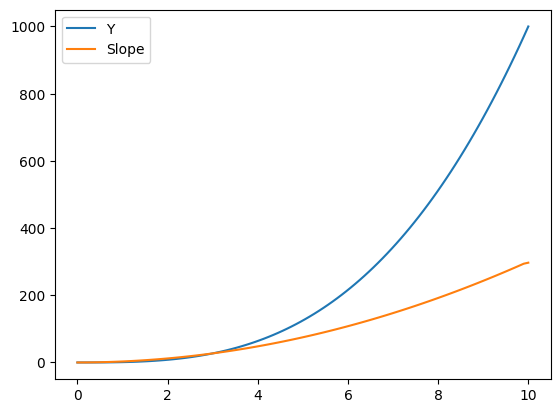

In [ ]:
x = np.linspace(0,10,100)
y = x**3
dy_dx = 3*x**2

slope = [fd(x,y)]
for i in range(1,len(x)-1):
  c_d = ((y[i+1] - y[i-1])/(x[i+1] - x[i-1]))
  slope.append(c_d)
slope.append(bd(x,y))

plt.plot(x,y)
plt.plot(x, slope)
plt.legend(["Y", "Slope"])

plt.show()

**Question 7.** Now try changing the size of your `x` array like we did with integration. See how your numerical differentiation answer changes when you use only 5 grid points, and when you use 500. Calculate the average percent error for these cases. Which is more accurate and why?

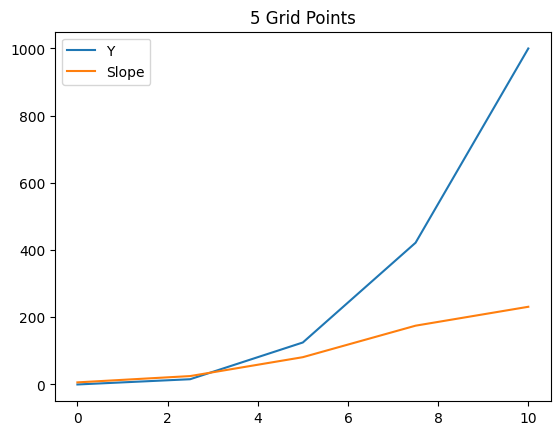

error: 13.657407407407405


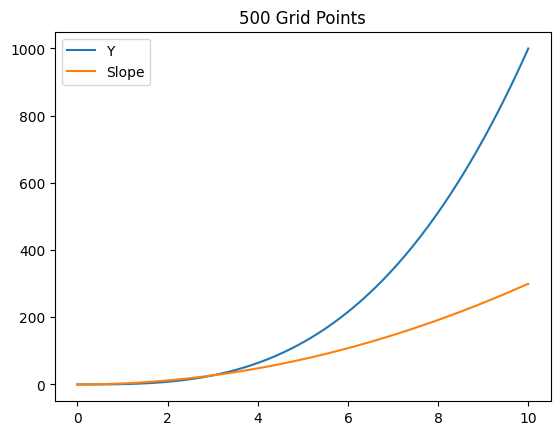

error: 0.1099290704977837


In [ ]:
x = np.linspace(0,10,5)
y = x**3
dy_dx = 3*x**2

slope1 = [fd(x,y)]
for i in range(1,len(x)-1):
  c_d = ((y[i+1] - y[i-1])/(x[i+1] - x[i-1]))
  slope1.append(c_d)
slope1.append(bd(x,y))

plt.plot(x,y)
plt.plot(x, slope1)
plt.legend(["Y", "Slope"])
plt.title("5 Grid Points")
plt.show()

error1 = []
for i in range(len(x)):
  error1.append(p_error(slope1[i], dy_dx[i]))
print("error:", (np.average(error1)))


x = np.linspace(0,10,500)
y = x**3
dy_dx = 3*x**2

slope2 = [fd(x,y)]
for i in range(1,len(x)-1):
  c_d = ((y[i+1] - y[i-1])/(x[i+1] - x[i-1]))
  slope2.append(c_d)
slope2.append(bd(x,y))

plt.plot(x,y)
plt.plot(x, slope2)
plt.legend(["Y", "Slope"])
plt.title("500 Grid Points")
plt.show()

error2 = []
for i in range(len(x)):
  error2.append(p_error(slope2[i], dy_dx[i]))
print("error:", (np.average(error2)))

**Using 500 grid points is more accurate because more data points leads to a more consistent, differentiable slope.**

Where do you see the accuracy of your numerical derivative suffer the most (as in for what value(s) of $x$)? Why do you think that is?

**Question 8.** Now try taking the derivative of our example function `y=x**4-10*x**3+5*(5-x)**2+2000` of the range of $x$ goes from 0 to 10. Then use the NumPy built in function `gradient` ([gradient help page](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html)) to take the same derivative, and compare the result to the function you wrote. How do they compare? Do you get the same answers?

In [ ]:
x = np.linspace(0,10,11)
y = x**4 - 10*x**3 + 5*(5-x)**2 + 2000
dy_dx = 4*x**3 - 30*x**2 - 10*(5-x)

grad = []
for i in range(len(x)):
  grad.append(4*(x[i])**3 - 30*(x[i])**2 - 10*(5-(x[i])))

print(grad)
print(np.gradient(y, edge_order=2))

[np.float64(-50.0), np.float64(-66.0), np.float64(-118.0), np.float64(-182.0), np.float64(-234.0), np.float64(-250.0), np.float64(-206.0), np.float64(-78.0), np.float64(158.0), np.float64(526.0), np.float64(1050.0)]
[ -36.  -72. -120. -180. -228. -240. -192.  -60.  180.  552.  996.]


**None of the answers are the same, but they are enough within a certain range of each other, that some sense of accuracy is reflected.**

# Working with real data sets

**Question 9.** One use of numerical integration is taking the average of a data set with uneven spacing between the data points. One example of this is a time series, where the data is stored at an uneven spacing in time.

Lots of computer models have uneven time spacing, because depending on the solution, sometimes we need to take smaller timesteps and sometimes we can take larger timesteps. This includes the code I use for modeling mantle convection.

The file data.t gives timeseries data for a mantle convection model. We will just work with the first two columns of this file: column 1 gives time (in a non-dimensional unit) and column 2 gives the average heat flux at the surface, also in non-dimensional units (these are columns 0 and 1 the way Python counts). Load the data into an array, and then plot this heat flux as a function of time. This data file is not a comma separated value file, or .csv, so you do NOT need to use the `delimiter=` option to load it.

In [ ]:
from google.colab import files
files.upload()
con_time = np.loadtxt("data.t", usecols=(0,1), unpack=True)

Saving data.t to data.t


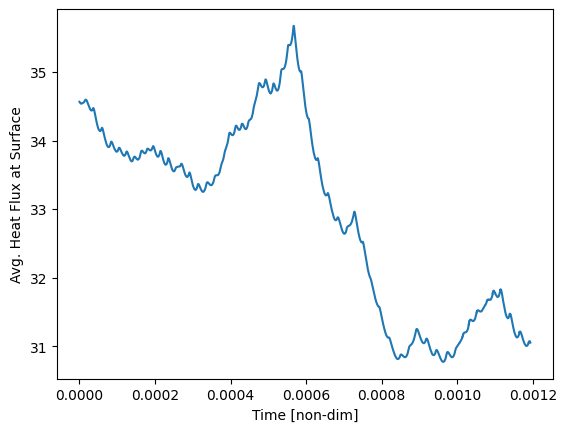

In [ ]:
time = np.array(con_time[0])
flux = np.array(con_time[1])

plt.plot(time, flux)
plt.xlabel("Time [non-dim]")
plt.ylabel("Avg. Heat Flux at Surface")

plt.show()

**Question 10.** Now we'll take the time average of this heat flux data set. Because the time spacing is uneven, we can't just take the average of the heat flux data. Instead we need use an integral:

$\frac{1}{t_{end}-t_{0}}\int_{t_0}^{t_{end}}f(t)dt$

where $f(t)$ is our heat flux as a function of time, $t$ is time, $t_{end}$ is the time at the end of the data set and $t_0$ the starting time of the dataset.

Use your integration function to find the time average of heatflux from the data.t file. Compare your answer to doing this the "wrong" way, were you just take the mean of all of the heat flux data, as if the time spacing was even.

In [ ]:
integral1 = (area(time, flux))/(time[(len(time)-1)] - time[0])
print("Correct: ", integral1)

integral2 = np.average(flux)
print("Incorrect: ", integral2)

Correct:  32.92970453989786
Incorrect:  33.093279328831024


**Question 11.** Now we will work with the file u000 from the last exercise, that contains the horizontal velocity field. After loading the data, plot just the velocity as a function of x at the top of the model (at the surface). In other words, if you reshape the array into a 2-D matrix like you did when plotting an image for horizontal velocity, this will be row 128. The result will be just a line plot.

The take the derivative of this surface velocity and plot this, to show regions where flow is converging and where it is diverging.

In [ ]:
from google.colab import files
files.upload()
hv = np.loadtxt("u000", usecols=(0,1,2), unpack=True)

Saving u000 to u000


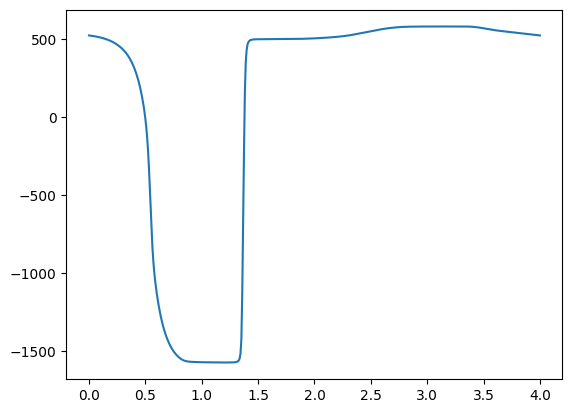

In [ ]:
h_vel = hv[2]
h_grid = np.reshape(h_vel, (128,513), order="F")
x = np.linspace(0,4,513)
y = h_grid[127]

plt.plot(x,y)
plt.show()

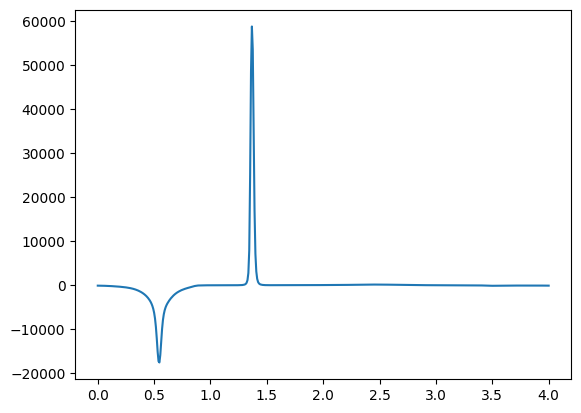

In [ ]:
slope = [fd(x,y)]
for i in range(1,len(x)-1):
  c_d = ((y[i+1] - y[i-1])/(x[i+1] - x[i-1]))
  slope.append(c_d)
slope.append(bd(x,y))

plt.plot(x, slope)
plt.show()

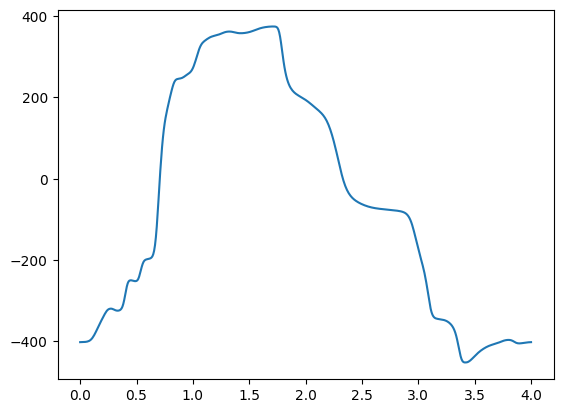

In [ ]:
h_vel = hv[2]
h_grid = np.reshape(h_vel, (128,513), order="F")
x = np.linspace(0,4,513)
y = h_grid[0]

plt.plot(x,y)
plt.show()

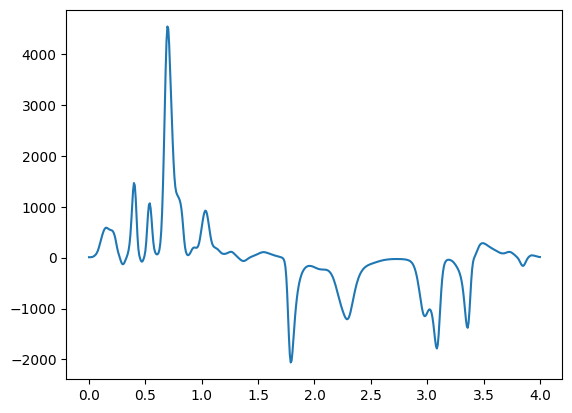

In [ ]:
slope = [fd(x,y)]
for i in range(1,len(x)-1):
  c_d = ((y[i+1] - y[i-1])/(x[i+1] - x[i-1]))
  slope.append(c_d)
slope.append(bd(x,y))

plt.plot(x, slope)
plt.show()